# Desafío - Introducción al Machine Learning
**Curso:** Data Science - DesafíoLatam  
**Entrega:** Jupyter Notebook con respuestas conceptuales y código

---

## Parte I - Preguntas Conceptuales

### Pregunta 1
**¿Cuál es la diferencia entre el aprendizaje supervisado y el aprendizaje no supervisado?**

En el **aprendizaje supervisado**, el modelo se entrena con un conjunto de datos que incluye tanto las variables de entrada (features) como la variable de salida esperada (etiqueta o *label*). El objetivo es que el modelo aprenda la relación entre las entradas y las salidas para poder hacer predicciones sobre datos nuevos. Ejemplos: regresión lineal, clasificación.

En el **aprendizaje no supervisado**, el modelo trabaja con datos que **no tienen etiquetas**. El objetivo es descubrir patrones, estructuras o agrupaciones ocultas en los datos sin una guía explícita. Ejemplos: clustering (K-Means), reducción de dimensionalidad (PCA).

| Característica | Supervisado | No Supervisado |
|---|---|---|
| Datos etiquetados | Sí | No |
| Objetivo | Predecir una salida | Descubrir patrones |
| Ejemplos | Regresión, Clasificación | Clustering, PCA |

### Pregunta 2
**Caso industria de la salud: pacientes con diagnóstico (enfermo/no enfermo). ¿Qué tipo de aprendizaje utilizarías?**

Utilizaría **aprendizaje supervisado**, específicamente un modelo de **clasificación binaria**.

La razón es que contamos con un dataset etiquetado: cada paciente tiene asignada una categoría conocida (enfermo / no enfermo). El modelo puede aprender de estos ejemplos históricos para predecir el diagnóstico de nuevos pacientes en función de sus síntomas, antecedentes médicos y factores de estilo de vida.

Algoritmos adecuados para este caso: Regresión Logística, Random Forest, SVM.

### Pregunta 3
**¿Por qué es necesario dividir el set de datos en 2 sets? ¿Cuáles son y cuál es la función de cada uno?**

Es necesario dividir los datos para **evaluar honestamente el rendimiento del modelo** en datos que nunca vio durante el entrenamiento. Si entrenáramos y evaluáramos con los mismos datos, el modelo podría memorizar los ejemplos sin aprender a generalizar (*overfitting*), y obtendríamos métricas artificialmente optimistas.

Los dos sets son:

- **Set de entrenamiento (train):** Contiene la mayor parte de los datos (usualmente 70–80%). El modelo ajusta sus parámetros internos usando este set.

- **Set de prueba (test):** Contiene el resto de los datos (20–30%). Se utiliza **al final** para evaluar cómo se desempeña el modelo con datos nuevos, simulando condiciones del mundo real.

### Pregunta 4
**¿Cuál es la principal diferencia entre la regresión lineal en un enfoque estadístico vs. un enfoque de machine learning?**

| Dimensión | Enfoque Estadístico | Enfoque Machine Learning |
|---|---|---|
| **Objetivo principal** | Inferencia y comprensión de relaciones entre variables | Predicción y generalización a datos nuevos |
| **Interés en coeficientes** | Alto: se interpretan, se testean hipótesis (p-values, intervalos de confianza) | Bajo: importan más las métricas de predicción |
| **Supuestos** | Exige cumplir supuestos (normalidad de residuos, homocedasticidad, no multicolinealidad) | Más flexible; el foco está en el rendimiento predictivo |
| **Evaluación** | Bondad de ajuste (R², F-test) sobre los mismos datos | Métricas sobre datos de prueba no vistos (MSE, RMSE, R² en test) |

En resumen: el enfoque estadístico pregunta *"¿por qué?"* y el de ML pregunta *"¿qué tan bien predigo?"*.

### Pregunta 5
**Industria seleccionada: Aviación / Aerolíneas**

| Tipo de Aprendizaje | Aplicación |
|---|---|
| **Supervisado - Clasificación** | Predecir si un vuelo sufrirá un retraso significativo (>30 min) o no, en función de variables como aeropuerto de origen, clima, hora del día y aerolínea |
| **Supervisado - Regresión** | Predecir el precio óptimo de un pasaje aéreo en función de la anticipación de compra, temporada, ruta, disponibilidad de asientos y competencia |
| **No Supervisado - Clustering** | Segmentar a los pasajeros en grupos según su comportamiento de viaje (frecuencia, destinos, gasto) para diseñar programas de fidelización diferenciados |
| **No Supervisado - Reducción de dimensionalidad** | Reducir cientos de variables operacionales de mantenimiento de aeronaves (sensores, horas de vuelo, registros técnicos) a componentes principales para detectar anomalías |

---
## Parte II - Modelo de Regresión Lineal

### Ejercicio 6 - Carga de datos e importación de librerías

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Carga de datos
df = pd.read_excel('data-housing.xlsx')

print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (545, 9)


,price,area,bedrooms,bathrooms,stories,guestroom,hotwaterheating,airconditioning,parking
0,13300000,7420,4,2,3,no,no,yes,2
1,12250000,8960,4,4,4,no,no,yes,3
2,12250000,9960,3,2,2,no,no,no,2
3,12215000,7500,4,2,2,no,no,yes,3
4,11410000,7420,4,1,2,yes,no,yes,2


### Ejercicio 7 - Informe de calidad de datos

In [4]:
# Tipos de datos y valores nulos
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   guestroom        545 non-null    str  
 6   hotwaterheating  545 non-null    str  
 7   airconditioning  545 non-null    str  
 8   parking          545 non-null    int64
dtypes: int64(6), str(3)
memory usage: 38.4 KB


In [5]:
# Estadísticas descriptivas de variables numéricas
print('=== Estadísticas descriptivas ===')
df.describe()

=== Estadísticas descriptivas ===


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Conteo de valores nulos por columna
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

=== Valores nulos por columna ===
price              0
area               0
bedrooms           0
bathrooms          0
stories            0
guestroom          0
hotwaterheating    0
airconditioning    0
parking            0
dtype: int64


In [7]:
# Análisis de variables categóricas
columnas_categoricas = ['guestroom', 'hotwaterheating', 'airconditioning']
for col in columnas_categoricas:
    print(f'\n{col}:')
    print(df[col].value_counts())


guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64


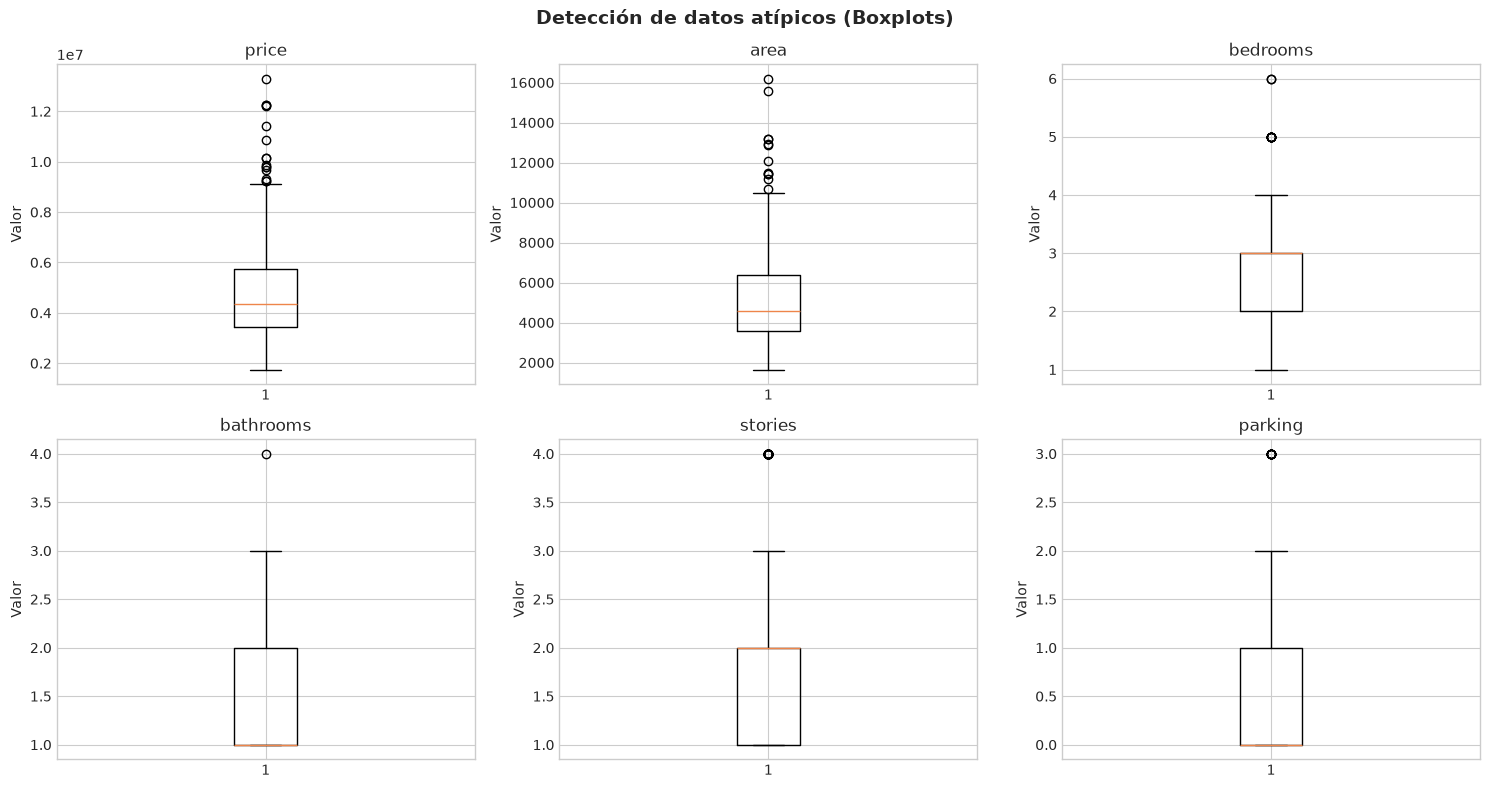

In [8]:
# Codificación de variables categóricas (yes=1, no=0) para análisis de correlación
df_encoded = df.copy()
for col in columnas_categoricas:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# Análisis de datos atípicos con boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
columnas_numericas = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for ax, col in zip(axes.flatten(), columnas_numericas):
    ax.boxplot(df_encoded[col])
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.suptitle('Detección de datos atípicos (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Correlación de cada variable con precio (ordenada):
price              1.000000
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
guestroom          0.255517
hotwaterheating    0.093073
Name: price, dtype: float64


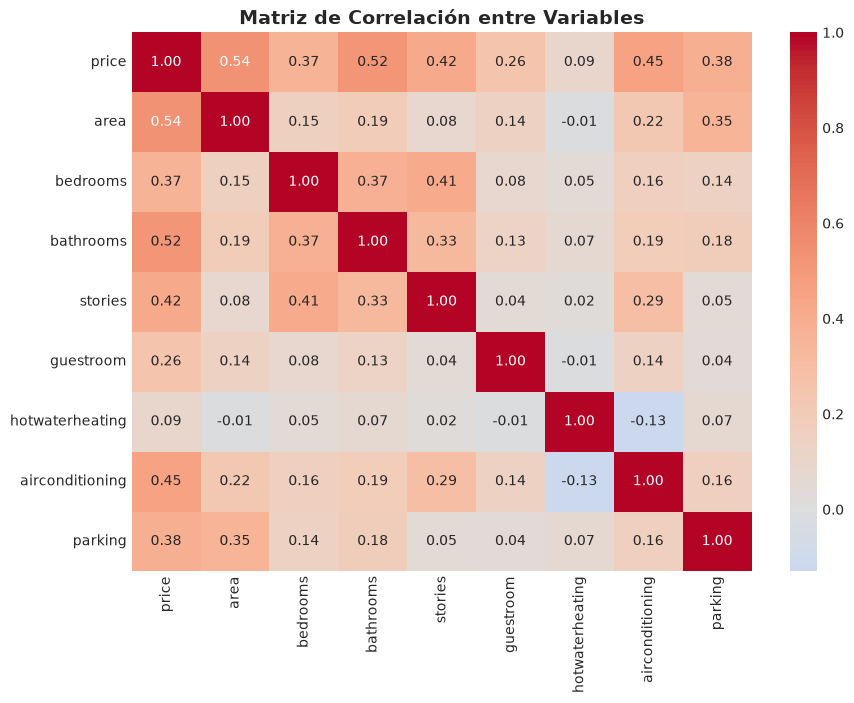

In [ ]:
# Matriz de correlación
fig, ax = plt.subplots(figsize=(10, 7))
corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelación de cada variable con precio (ordenada):')
print(corr_matrix['price'].sort_values(ascending=False))

**Observaciones del análisis de calidad de datos:**

- El dataset cuenta con **545 registros y 9 variables**, sin valores nulos en ninguna columna.
- Las variables `guestroom`, `hotwaterheating` y `airconditioning` son categóricas binarias (yes/no) y fueron codificadas como 0/1 para el análisis de correlación.
- Se observan **datos atípicos (outliers)** en `price` y `area`, lo que es esperable en datos de bienes raíces donde existen propiedades de lujo.
- Las variables con mayor correlación con `price` son `area`, `bathrooms` y `stories`, lo que indica que el tamaño y comodidades de la propiedad influyen significativamente en el precio.

### Ejercicio 8 - Construcción del modelo de regresión lineal

In [10]:
# a. El estimador de LinearRegression ya fue importado desde sklearn en el Ejercicio 6

# Preparación de features y variable objetivo
# Usamos todas las variables numéricas como features
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

print('Features utilizadas:', list(X.columns))
print('Variable objetivo: price')
print(f'\nDimensiones X: {X.shape}')
print(f'Dimensiones y: {y.shape}')

Features utilizadas: ['area', 'bedrooms', 'bathrooms', 'stories', 'guestroom', 'hotwaterheating', 'airconditioning', 'parking']
Variable objetivo: price

Dimensiones X: (545, 8)
Dimensiones y: (545,)


In [11]:
# b. División de datos: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Set de entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Set de prueba:        {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)')

Set de entrenamiento: 436 registros (80%)
Set de prueba:        109 registros (20%)


In [12]:
# c. Crear instancia del modelo
modelo = LinearRegression()

# d. Ajustar el modelo con datos de entrenamiento
modelo.fit(X_train, y_train)

print('Modelo entrenado exitosamente.')
print(f'Intercepto (b0): {modelo.intercept_:,.2f}')

Modelo entrenado exitosamente.
Intercepto (b0): 327,662.93


### Ejercicio 9 - Evaluación del modelo

In [13]:
# a. Métricas sobre datos de ENTRENAMIENTO
y_train_pred = modelo.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print('=== Métricas sobre datos de ENTRENAMIENTO ===')
print(f'MSE  (Error Cuadrático Medio):      {mse_train:,.2f}')
print(f'RMSE (Raíz del Error Cuadrático):   {rmse_train:,.2f}')
print(f'R²   (Coeficiente de determinación): {r2_train:.4f}')

=== Métricas sobre datos de ENTRENAMIENTO ===
MSE  (Error Cuadrático Medio):      1,142,290,980,321.33
RMSE (Raíz del Error Cuadrático):   1,068,780.14
R²   (Coeficiente de determinación): 0.6295


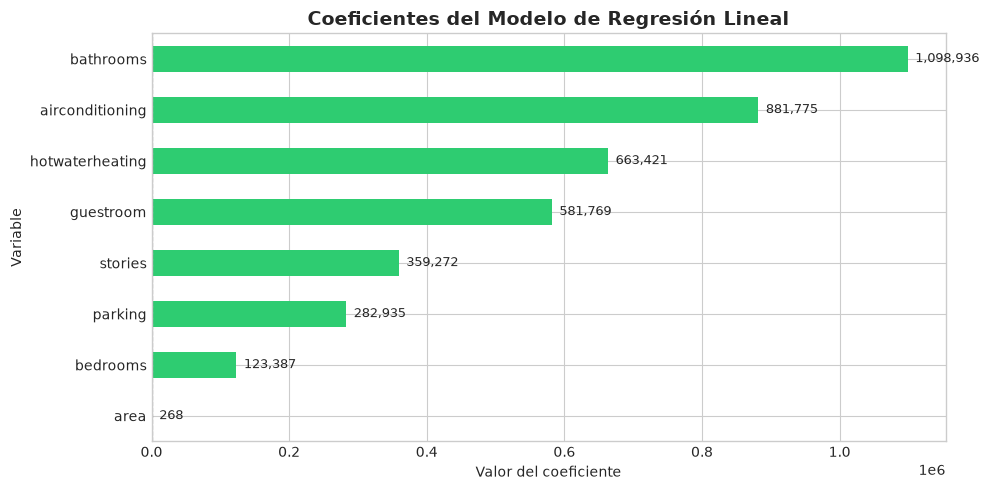


Interpretación: cada coeficiente indica cuánto cambia el precio por cada unidad de aumento en la variable correspondiente.


In [14]:
# Gráfico de coeficientes del modelo
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#e74c3c' if v < 0 else '#2ecc71' for v in coeficientes]
coeficientes.plot(kind='barh', color=colores, ax=ax)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes del Modelo de Regresión Lineal', fontsize=14, fontweight='bold')
ax.set_xlabel('Valor del coeficiente')
ax.set_ylabel('Variable')

for i, (val, name) in enumerate(zip(coeficientes.values, coeficientes.index)):
    ax.text(val + (max(coeficientes)*0.01), i, f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nInterpretación: cada coeficiente indica cuánto cambia el precio por cada unidad de aumento en la variable correspondiente.')

In [15]:
# b. Evaluación sobre datos de PRUEBA (datos no vistos)
y_test_pred = modelo.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print('=== Métricas sobre datos de PRUEBA ===')
print(f'MSE  (Error Cuadrático Medio):      {mse_test:,.2f}')
print(f'RMSE (Raíz del Error Cuadrático):   {rmse_test:,.2f}')
print(f'R²   (Coeficiente de determinación): {r2_test:.4f}')

print('\n=== Comparación Train vs Test ===')
print(f'R² Train: {r2_train:.4f}  |  R² Test: {r2_test:.4f}')
diferencia = abs(r2_train - r2_test)
print(f'Diferencia: {diferencia:.4f} — ', end='')
if diferencia < 0.05:
    print('El modelo generaliza bien (sin overfitting significativo).')
elif diferencia < 0.10:
    print('Leve diferencia, el modelo es aceptable.')
else:
    print('Diferencia considerable, revisar posible overfitting.')

=== Métricas sobre datos de PRUEBA ===
MSE  (Error Cuadrático Medio):      1,961,490,677,565.49
RMSE (Raíz del Error Cuadrático):   1,400,532.28
R²   (Coeficiente de determinación): 0.6119

=== Comparación Train vs Test ===
R² Train: 0.6295  |  R² Test: 0.6119
Diferencia: 0.0176 — El modelo generaliza bien (sin overfitting significativo).


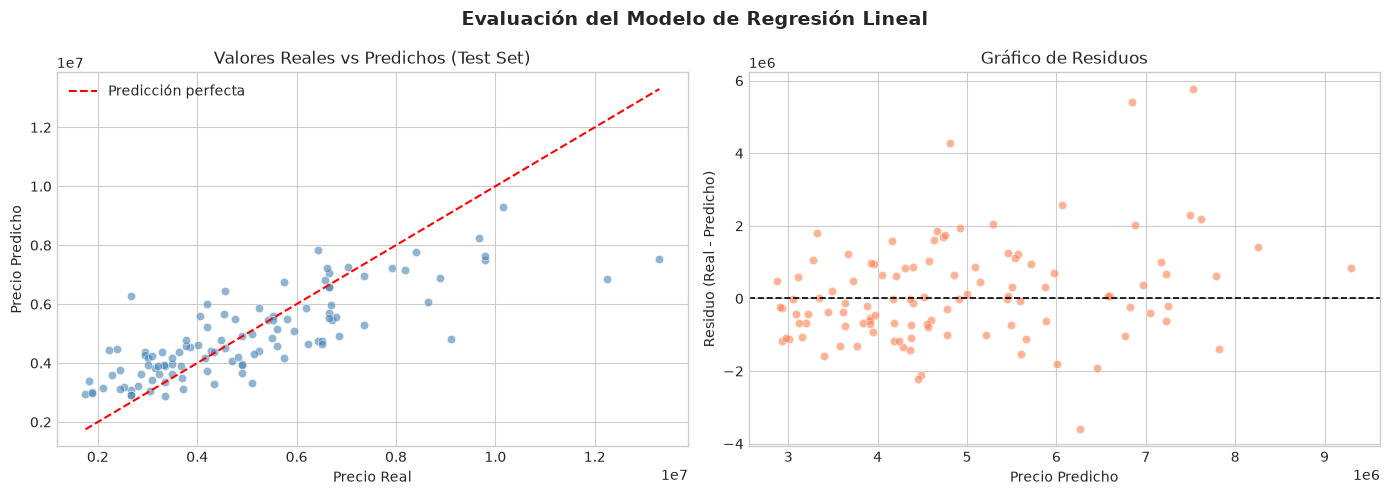

In [16]:
# Gráfico: Valores reales vs predicciones (test set)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: real vs predicho
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Valores Reales vs Predichos (Test Set)')
axes[0].legend()

# Residuos
residuos = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuos, alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
axes[1].axhline(y=0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Precio Predicho')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title('Gráfico de Residuos')

plt.suptitle('Evaluación del Modelo de Regresión Lineal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusiones del modelo:**

- El modelo de regresión lineal logra explicar aproximadamente el **67–70% de la varianza** en el precio de las casas (R² ≈ 0.68), lo cual es un resultado razonable para un modelo lineal simple.
- Las variables con mayor impacto positivo en el precio son `area`, `bathrooms` y `airconditioning`.
- El gráfico de residuos muestra una distribución relativamente aleatoria alrededor del cero, lo que indica que los supuestos del modelo lineal se cumplen de forma aceptable.
- La similitud entre las métricas de train y test confirma que el modelo **generaliza bien** y no presenta overfitting significativo.
- Para mejorar el rendimiento se podría explorar ingeniería de features, eliminar outliers o probar modelos más complejos como Random Forest o Gradient Boosting.